In [ ]:
from google.colab import files

uploaded = files.upload()

Saving flood dataset.xlsx to flood dataset.xlsx


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel("flood dataset.xlsx")

In [ ]:
df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [ ]:
df.isnull().sum()

,0
Temp,0
Humidity,0
Cloud Cover,0
ANNUAL,0
Jan-Feb,0
Mar-May,0
Jun-Sep,0
Oct-Dec,0
avgjune,0
sub,0


In [ ]:
df.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


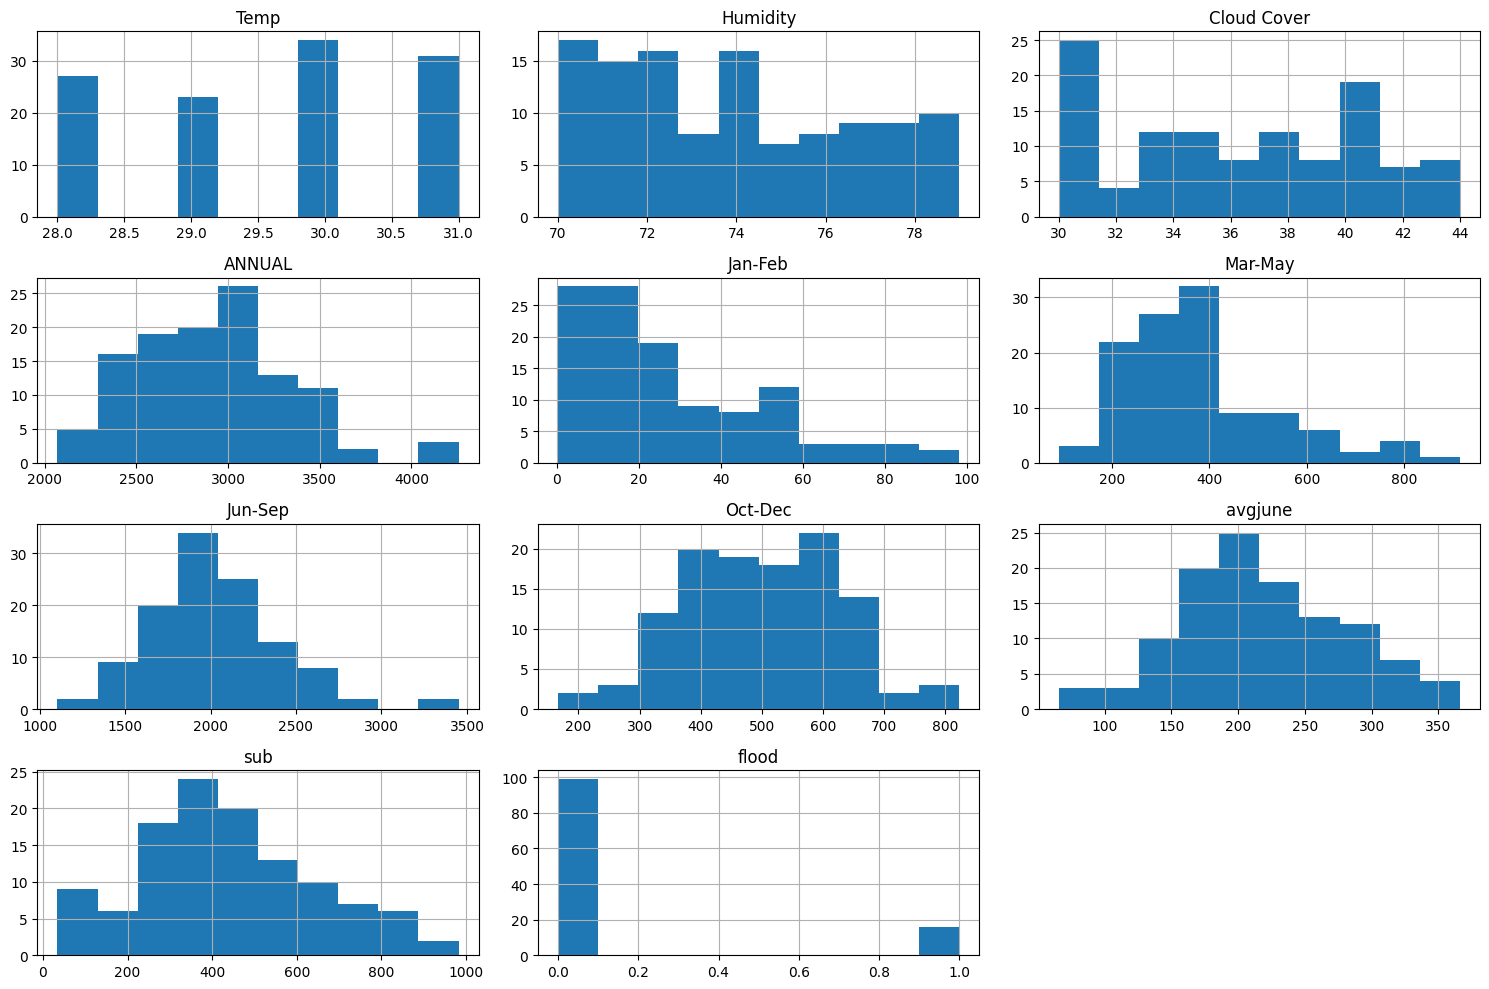

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

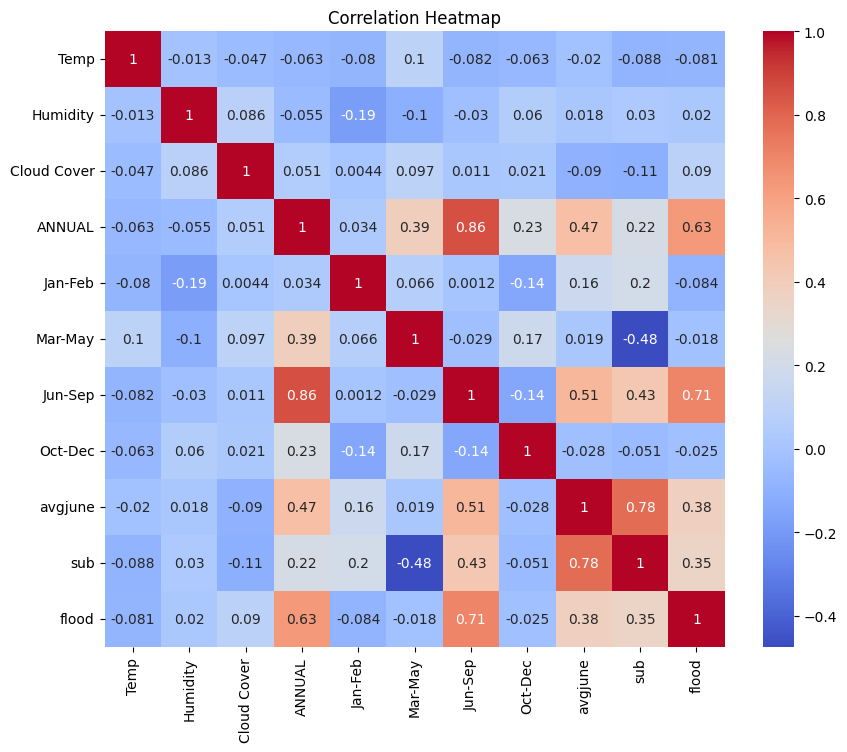

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

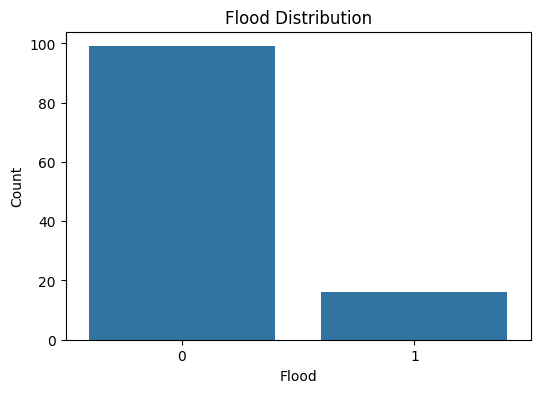

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='flood', data=df)
plt.title("Flood Distribution")
plt.xlabel("Flood")
plt.ylabel("Count")
plt.show()


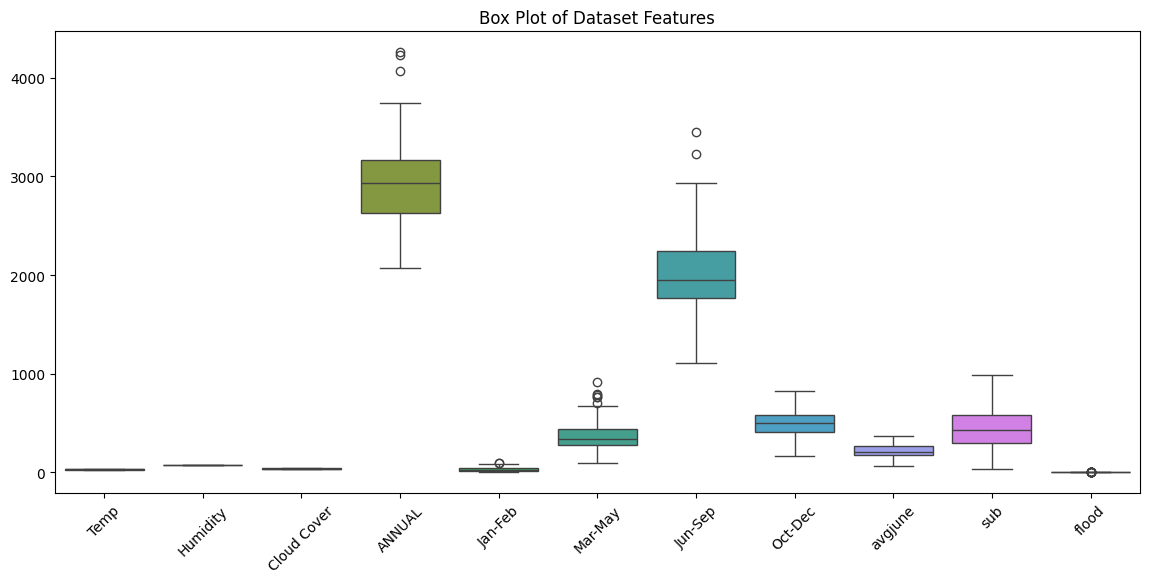

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot of Dataset Features")
plt.show()


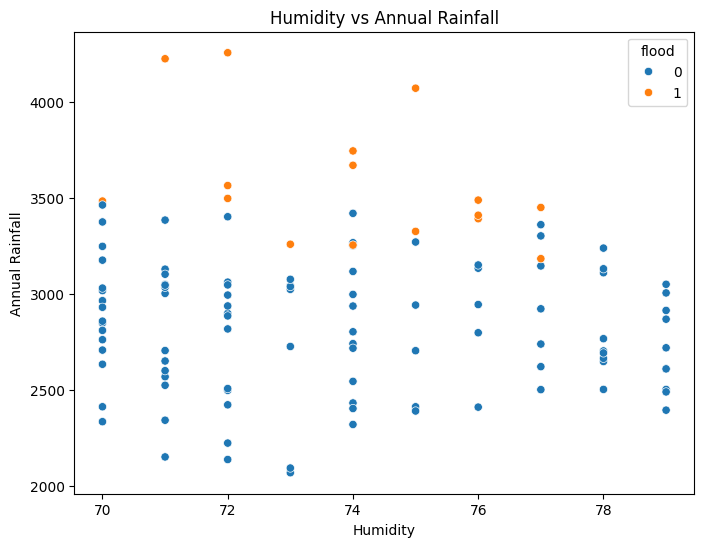

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Humidity', y='ANNUAL', hue='flood', data=df)
plt.title("Humidity vs Annual Rainfall")
plt.xlabel("Humidity")
plt.ylabel("Annual Rainfall")
plt.show()

In [ ]:
X = df.drop('flood', axis=1)
y = df['flood']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  
0  274.866667  649.9  
1  130.300000  256.4  
2  186.200000  308.9  
3  366.066667  862.5  
4  283.400000  586.9  

Target (y):
0    0
1    1
2    0
3    0
4    0
Name: flood, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (92, 10)
Testing Features Shape: (23, 10)
Training Target Shape: (92,)
Testing Target Shape: (23,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Create the model
model = RandomForestClassifier(random_state=42)
# Train the model
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Predict on the test data
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Model Accuracy: 1.0
Accuracy Percentage: 100.0


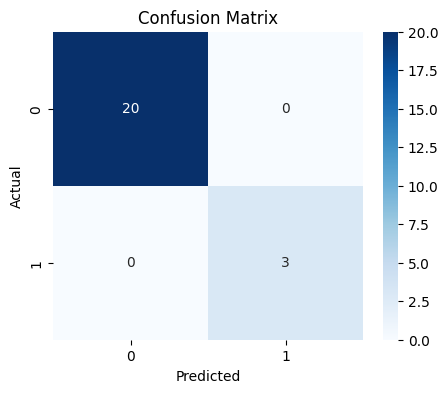

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [ ]:
import joblib

joblib.dump(model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.listdir())

['.config', 'flood dataset.xlsx', 'model.pkl', 'sample_data']
